# Componente A — Overview de experimentos

**Detección de anomalías en rendimientos agrícolas** (soja/maíz, Argentina).
Modelo no supervisado: se entrena solo con campañas *normales* y puntúa por
desviación. La etiqueta proxy es `z_rinde < -1.5` (caída de rinde vs la media móvil
del propio departamento). El detector nunca ve la etiqueta — solo se usa para evaluar.

**Métrica principal: PR-AUC** (libre de umbral). Las features son climáticas
(promedios mensuales Sep–Mar de ~9 variables = 54 features).

Estos notebooks reconstruyen los experimentos **desde los runs guardados en
`runs/`** (no re-entrenan). Índice:

| notebook | contenido |
|---|---|
| `01` | Modelos base (AE/DAE/VAE) + búsqueda de hiperparámetros |
| `02` | Ensembles (seed-ensemble, AE/DAE, heterogéneo) |
| `03` | Híbridos (AE-latente+IForest) y scoring alternativo |
| `04` | Features nuevas (limpieza de datos, NDVI, ERA5 suelo/heladas, agro) |
| `05` | Métodos modernos (deepod) + techo estructural |

In [1]:
import explib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110

## Leaderboard final (panel limpio, test PR-AUC media±std)

In [2]:
explib.show(explib.tbl_leaderboard())

,model,desc,soja_pr,soja_std,maiz_pr,maiz_std
0,vae_seedens_v1 ⭐,VAE seed-ensemble (lat16),0.592,0.010,0.508,0.005
1,vae_seedens_deep,VAE seed-ensemble (deep),0.585,0.007,0.500,0.003
2,vae_v4 (single),VAE recon_prob single,0.559,0.035,0.479,0.070
3,vae_v15 (single),VAE recon_prob deep single,0.553,0.036,0.489,0.060
4,iforest_v2,Isolation Forest (mf=0.3),0.511,0.031,0.492,0.030


### Comparación final de los modelos, con desvío estándar (¿cuál es mejor?)

/Users/joaquin/Documents/facultad /ml/tp final/Trabajo_final_ML/experiments/explib.py:201: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  ax.legend(); ax.grid(axis="x", alpha=0.3); fig.tight_layout(); return fig
/Users/joaquin/Documents/facultad /ml/tp final/Trabajo_final_ML/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


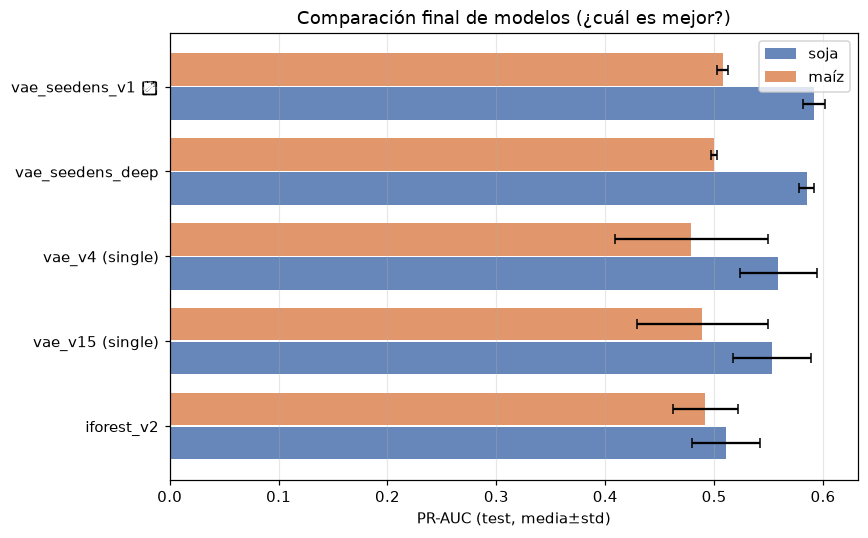

In [3]:
explib.plot_leaderboard_compare(); plt.show()

**Conclusión:** el mejor modelo es el **seed-ensemble del VAE con score
`recon_prob`** (soja 0.592, maíz 0.508), y su **desvío es diminuto** (±0.005–0.010)
frente al VAE single (±0.035–0.070) — gana no solo en promedio sino en el peor caso.
Dos palancas dominaron el proyecto: la **limpieza de datos** (notebook 04) y el
**score probabilístico + ensemble de semillas** (notebooks 01–02). El resto
(features satelitales, métodos modernos) no superó al base — ver notebooks 04–05.

### Todas las métricas del modelo ganador (test, con ±std entre seeds)

In [4]:
explib.show(explib.run_metrics("vae_seedens_v1", "soja"))

,metrica,valor,std
0,PR-AUC,0.5921,0.0101
1,ROC-AUC,0.7380,0.0050
2,F1,0.4667,0.0008
3,Precision@k,0.5577,0.0128
4,Recall@contam,0.2970,0.0018


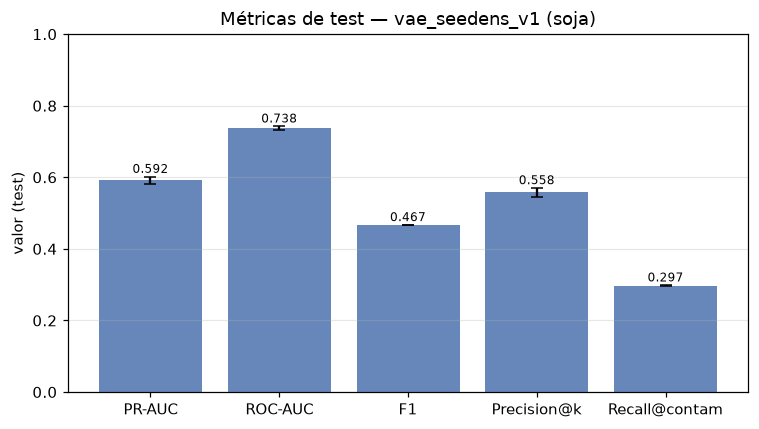

In [5]:
explib.plot_all_metrics("vae_seedens_v1", "soja"); plt.show()